In [ ]:
import torch.nn.functional as F
import torch.optim as optim
import torch
import torch.nn as nn
import os
from pathlib import Path
import pickle
import numpy as np

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    use_cuda = True
else:
    device = torch.device("cpu")
    use_cuda = False

print(device)

cpu


In [ ]:
class SmallRGBNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: [3 → 16] conv + relu + pool
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)  # (bs, 16, 28,28)
        # Block 2: [16 → 32]
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # (bs, 32, 14,14)
        # Block 3: [32 → 64]
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # (bs,64,7,7)
        # AdaptiveAvgPool2d(1) reduces (64,7,7) → (64,1,1)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        # Fully connected classifier
        self.fc = nn.Linear(64, 5)  # 5 clases

    def forward(self, x):
        # x: [bs, 3, 28, 28]
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = self.avgpool(x)

        x = x.view(x.size(0), -1)

        return self.fc(x)



# Training

In [ ]:
loss_fn = nn.CrossEntropyLoss()
test_loss_fn = nn.CrossEntropyLoss(reduction='sum')
model = SmallRGBNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

savedir = 'results'
if not os.path.exists(savedir):
    os.makedirs(savedir)

In [ ]:
def train(model, train_loader, optimizer, epoch):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for batch_idx, (inputs, target) in enumerate(train_loader):
        inputs, target = inputs.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = output.argmax(dim=1)
        correct += (preds == target).sum().item()
        total += inputs.size(0)

        if batch_idx % 10 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch,
                batch_idx * len(inputs),
                len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item()))

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


# Test

In [ ]:
def test(model, test_loader):
    model.eval()

    test_loss = 0
    correct = 0
    test_size = 0

    with torch.no_grad():
        for inputs, target in test_loader:
            inputs, target = inputs.to(device), target.to(device)

            output = model(inputs)

            test_loss += test_loss_fn(output, target).item()
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()

            test_size += inputs.size(0)

    test_loss /= test_size
    accuracy = correct / test_size

    print('Test set: Avg loss: {:.4f}, Acc: {}/{} ({:.0f}%)'.format(
        test_loss, correct, test_size, 100. * accuracy))

    return test_loss, accuracy


# Dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader
class RetinaRGBDataset(Dataset):
    def __init__(self, images, labels=None):
        self.images = images   # (N,3,H,W)
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx]).float()

        if self.labels is None:
            return img

        label = int(self.labels[idx])
        if isinstance(label, np.ndarray):
            label = label.item()

        return img, label



# Load

In [ ]:
def load(path):
    with open(path, 'rb') as file:
        data = pickle.load(file)
    return data

def get_train_images_labels(data):
    images = data['images']
    labels = data['labels']
    return images, labels

def get_test_images(data):
    return data['images']

def train_preprocessing_rgb(images):
  X = images.astype(np.float32) / 255.0
  mean = X.mean(axis=(0,1,2))
  std  = X.std(axis=(0,1,2)) + 1e-8
  X_norm = (X - mean) / std
  X_norm = np.transpose(X_norm, (0,3,1,2))
  return X_norm, mean, std

def preprocessing_test_rgb(images, mean, std):
    X = images.astype(np.float32) / 255.0
    X_norm = (X - mean) / std
    X_norm = np.transpose(X_norm, (0,3,1,2))
    return X_norm

In [ ]:
BASE_DIR = Path.cwd()
train_path = next(BASE_DIR.rglob("train_data.pkl"), None)
test_path  = next(BASE_DIR.rglob("test_data.pkl"), None)

train_data = load(train_path)
test_data  = load(test_path)

train_images, train_labels = get_train_images_labels(train_data)
test_images = get_test_images(test_data)

train_labels = np.array(train_labels).astype(np.int64)

# Preprocess train and test images
X_norm, mean, std = train_preprocessing_rgb(train_images)
X_test_norm = preprocessing_test_rgb(test_images, mean, std)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_tr, X_val, y_tr, y_val = train_test_split(
    X_norm,
    train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

In [ ]:
# Datasets and dataloaders
train_dataset = RetinaRGBDataset(X_tr, y_tr)
val_dataset   = RetinaRGBDataset(X_val, y_val)
test_dataset  = RetinaRGBDataset(X_test_norm)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

for epoch in range(1, 71):
    train_loss, train_acc = train(model, train_loader, optimizer, epoch)    # training on train set
    val_loss, val_acc = test(model, val_loader)     # evaluation on validation set

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)



/tmp/ipython-input-3051378188.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


Train Epoch: 1 [0/864 (0%)]	Loss: 1.618702
Train Epoch: 1 [320/864 (37%)]	Loss: 1.619654
Train Epoch: 1 [640/864 (74%)]	Loss: 1.580015
Test set: Avg loss: 1.5567, Acc: 97/216 (45%)
Train Epoch: 2 [0/864 (0%)]	Loss: 1.542041
Train Epoch: 2 [320/864 (37%)]	Loss: 1.497884
Train Epoch: 2 [640/864 (74%)]	Loss: 1.547734
Test set: Avg loss: 1.4299, Acc: 97/216 (45%)
Train Epoch: 3 [0/864 (0%)]	Loss: 1.441469
Train Epoch: 3 [320/864 (37%)]	Loss: 1.397038
Train Epoch: 3 [640/864 (74%)]	Loss: 1.331978
Test set: Avg loss: 1.3713, Acc: 97/216 (45%)
Train Epoch: 4 [0/864 (0%)]	Loss: 1.423260
Train Epoch: 4 [320/864 (37%)]	Loss: 1.203205
Train Epoch: 4 [640/864 (74%)]	Loss: 1.345535
Test set: Avg loss: 1.3528, Acc: 97/216 (45%)
Train Epoch: 5 [0/864 (0%)]	Loss: 1.290859
Train Epoch: 5 [320/864 (37%)]	Loss: 1.228107
Train Epoch: 5 [640/864 (74%)]	Loss: 1.222221
Test set: Avg loss: 1.3452, Acc: 97/216 (45%)
Train Epoch: 6 [0/864 (0%)]	Loss: 1.546817
Train Epoch: 6 [320/864 (37%)]	Loss: 1.343254
Train 

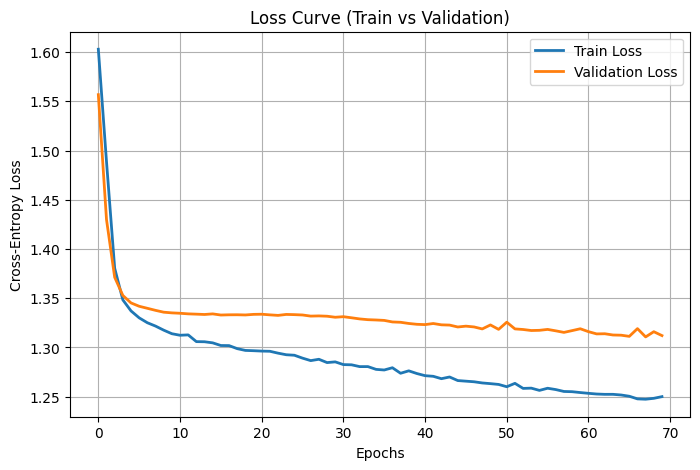

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.title("Loss Curve (Train vs Validation)")
plt.legend()
plt.grid(True)
plt.show()

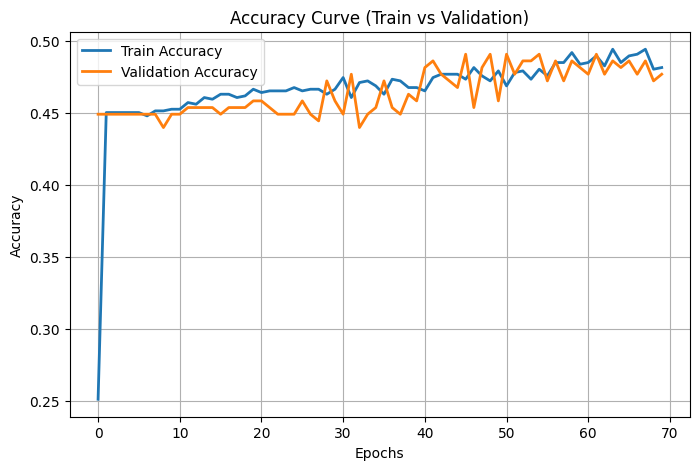

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy", linewidth=2)
plt.plot(val_accs, label="Validation Accuracy", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve (Train vs Validation)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def predict(model, test_loader):
    model.eval()
    preds = []

    with torch.no_grad():
        for inputs in test_loader:
            inputs = inputs.to(device)
            output = model(inputs)
            pred = output.argmax(dim=1)
            preds.extend(pred.cpu().numpy())

    return np.array(preds)

In [ ]:
import pandas as pd
def create_submission_csv(preds, filename):
    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["ID", "Label"])
        for i, label in enumerate(preds, start=1):
            writer.writerow([i, int(label)])


In [ ]:
test_preds = predict(model, test_loader)
create_submission_csv(test_preds, "submission_cnn_rgb_manual2.csv")


In [ ]:
from google.colab import files
files.download("submission_cnn_rgb_manual2.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def get_all_preds(model, loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    return all_targets, all_preds

In [ ]:
from sklearn.metrics import classification_report
y_true, y_pred = get_all_preds(model, val_loader)
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.56      0.85      0.67        97
           1       0.25      0.04      0.07        26
           2       0.21      0.17      0.19        41
           3       0.42      0.33      0.37        39
           4       0.00      0.00      0.00        13

    accuracy                           0.48       216
   macro avg       0.29      0.28      0.26       216
weighted avg       0.40      0.48      0.41       216



/tmp/ipython-input-3051378188.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1